
# Urbanization and Seasonal Behavior Clustering

This notebook analyzes seasonal vegetation patterns across Kerala, India, using phenological data and geospatial clustering. The goal is to explore how plant seasonal behaviors vary across locations and how these behaviors relate to urbanization, approximated using nighttime radiance data.

The key steps include:
- Loading and aggregating seasonal phenology data
- Clustering locations based on phenophase patterns
- Visualizing clusters geographically
- Comparing patterns between high and low radiance areas


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../../data/spring_2025_data/cleaned_alldata_with_urbanization.csv"
data = pd.read_csv(file_path)


## Aggregating Phenological Data by Location

We group observations by unique geographic coordinates (`Lat`, `Long`) and compute the mean value for each phenological variable (e.g., `Leaves_fresh`, `Flowers_bud`). This captures the average seasonal behavior at each location over time.

Missing values are filled with `-2` to indicate absence of data in DBSCAN-compatible format.


In [2]:
# Aggregating data by location (Lat, Long) to capture seasonal behavior trends
# Using the mean to summarize each seasonal attribute over time for each unique location

seasonal_columns = [
    "Leaves_fresh",
    "Leaves_mature",
    "Leaves_old",
    "Flowers_bud",
    "Flowers_open",
    "Flowers_male",
    "Flowers_Female",
    "Fruits_unripe",
    "Fruits_ripe",
    "Fruits_open",
]

# Aggregating by Lat and Long
aggregated = data.groupby(["Lat", "Long"])[seasonal_columns].mean().reset_index()

# Display the aggregated data to review the summary statistics
aggregated.head()


,Lat,Long,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open
0,-38.25502,100.00000,2.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0
1,-38.20166,100.00000,0.0,0.0,0.0,2.0,2.0,-2.0,-2.0,0.0,0.0,-2.0
2,-36.19894,100.00000,2.0,1.0,1.0,0.0,-2.0,0.0,0.0,0.0,0.0,-2.0
3,-32.92713,23.85847,0.0,2.0,1.0,0.0,0.0,-2.0,-2.0,0.0,2.0,-2.0
4,-29.91685,100.00000,2.0,2.0,0.0,0.0,0.0,-2.0,-2.0,2.0,2.0,1.0


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

aggregated_filled = aggregated.fillna(-2)

# Separate Lat and Long for clustering
lat_long = aggregated_filled[["Lat", "Long"]].values
seasonal_data = aggregated_filled.drop(["Lat", "Long"], axis=1)

# Scale the seasonal data
scaler = StandardScaler()
seasonal_data_scaled = scaler.fit_transform(seasonal_data)

# Using DBSCAN with default settings for now; parameters may need tuning
dbscan = DBSCAN(eps=1.5, min_samples=10)
clusters = dbscan.fit_predict(seasonal_data_scaled)

# Add cluster labels back to the original data
aggregated_filled["Cluster"] = clusters

# Display the resulting clusters to understand groupings
aggregated_filled["Cluster"].value_counts(), aggregated_filled.head()


( 0     33626
 -1      1524
  1        63
  7        51
  3        35
  9        25
  4        17
  5        12
  2        10
  6        10
  11       10
  8         7
  10        7
  12        5
 Name: Cluster, dtype: int64,
         Lat       Long  Leaves_fresh  Leaves_mature  Leaves_old  Flowers_bud  \
 0 -38.25502  100.00000           2.0            1.0         1.0          1.0   
 1 -38.20166  100.00000           0.0            0.0         0.0          2.0   
 2 -36.19894  100.00000           2.0            1.0         1.0          0.0   
 3 -32.92713   23.85847           0.0            2.0         1.0          0.0   
 4 -29.91685  100.00000           2.0            2.0         0.0          0.0   
 
    Flowers_open  Flowers_male  Flowers_Female  Fruits_unripe  Fruits_ripe  \
 0           2.0           0.0             0.0            0.0          0.0   
 1           2.0          -2.0            -2.0            0.0          0.0   
 2          -2.0           0.0             0.0      


## Clustering with DBSCAN

We use the DBSCAN algorithm to identify clusters of locations with similar phenophase profiles. This method is density-based and does not require the number of clusters to be pre-specified.

- Input features: standardized seasonal behavior columns
- `eps=1.5` and `min_samples=10` are used as initial clustering parameters
- The output is a `Cluster` label assigned to each location


In [ ]:
# Cluster profiling: summarize mean phenological behavior for each cluster
cluster_profiles = aggregated_filled.groupby("Cluster")[seasonal_columns].mean()
print("Cluster Profiles (mean of each phenological feature):")
display(cluster_profiles)

# Cluster size (including outliers)
print("Number of observations in each cluster:")
display(aggregated_filled["Cluster"].value_counts())


Cluster Profiles (mean of each phenological feature):


,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open
Cluster,,,,,,,,,,
-1,0.783103,1.067540,0.261905,-0.089814,-0.342837,-1.052245,-1.090737,0.057774,0.212935,-1.106657
0,1.093399,1.734376,0.515346,0.367180,0.311507,-1.661814,-1.664182,0.432681,0.273289,-1.441994
1,0.158730,-2.000000,-2.000000,-1.984127,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
2,-2.000000,2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,1.600000,-2.000000,-2.000000
3,1.042857,2.000000,0.957143,-2.000000,-2.000000,0.014286,-0.028571,0.542857,0.314286,-2.000000
4,-1.952941,1.002941,0.821569,-2.000000,-2.000000,-2.000000,-2.000000,-1.917647,0.841176,-2.000000
5,-2.000000,1.000000,1.250000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
6,-2.000000,-2.000000,-2.000000,-2.000000,1.800000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
7,1.000000,-2.000000,-2.000000,-2.000000,1.980392,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000


Number of observations in each cluster:


 0     33626
-1      1524
 1        63
 7        51
 3        35
 9        25
 4        17
 5        12
 2        10
 6        10
 11       10
 8         7
 10        7
 12        5
Name: Cluster, dtype: int64


## Visualizing Clusters on the Map

We plot the spatial distribution of clusters on a map of India, focusing on Kerala. This helps us understand geographic patterns of phenological similarity.

Clusters are color-coded and plotted over approximate regional boundaries using either basemaps or latitude/longitude.


In [5]:
import geopandas as gpd
from shapely.geometry import Point

# Convert Lat/Long data to geometric points and plot on a basemap of India (Kerala region focus)
# Loading a base map with Indian states boundaries for reference
# Kerala-specific state boundary can be used to better contextualize the data

# Create geometry column using Lat and Long for Kerala points
geometry = [
    Point(xy) for xy in zip(aggregated_filled["Long"], aggregated_filled["Lat"])
]
kerala_gdf = gpd.GeoDataFrame(aggregated_filled, geometry=geometry)

# Load India states shapefile for reference and filter Kerala (using any available map layer if present)
try:
    india_states = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    kerala_boundary = india_states[
        (india_states["name"] == "India") & (india_states["geometry"].type == "Polygon")
    ]

    # Plot Kerala with clusters overlay
    fig, ax = plt.subplots(figsize=(12, 12))
    kerala_boundary.plot(ax=ax, color="lightgrey", edgecolor="black")
    kerala_gdf.plot(
        column="Cluster", ax=ax, cmap="tab20", markersize=10, legend=True, alpha=0.6
    )

    plt.title("Geographic Clustering of Seasonal Behavior in Kerala with Basemap")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

except Exception as e:
    str(e)



## Cluster Profiling

We summarize each cluster by calculating the mean of all phenophase features. This helps characterize the dominant vegetative behavior of each group.

We also count how many locations fall into each cluster to gauge their spatial prevalence.


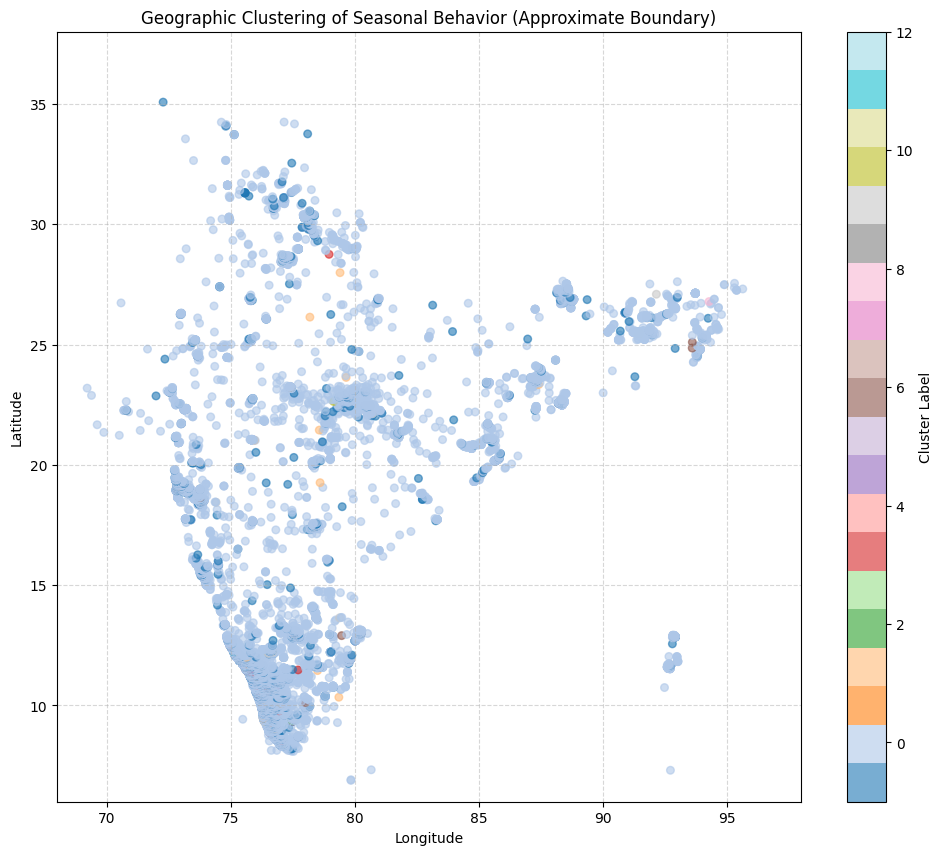

In [6]:
# Redrawing the Kerala clustering with an estimated outline using latitude and longitude boundaries for visualization purposes
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    aggregated_filled["Long"],
    aggregated_filled["Lat"],
    c=aggregated_filled["Cluster"],
    cmap="tab20",
    s=30,
    alpha=0.6,
)

plt.xlim(68, 98)
plt.ylim(6, 38)

plt.colorbar(scatter, label="Cluster Label")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Clustering of Seasonal Behavior (Approximate Boundary)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


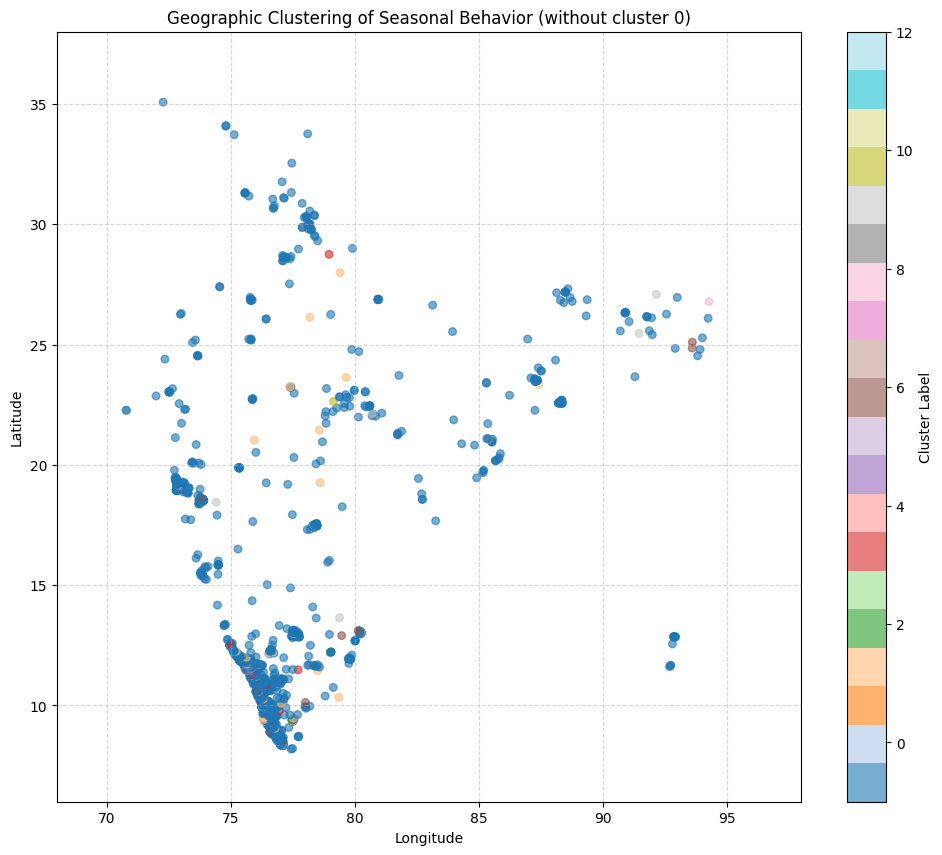

In [7]:
kerala_clusters_no_main = aggregated_filled[aggregated_filled["Cluster"] != 0]

# Plot the remaining clusters without Cluster 0
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    kerala_clusters_no_main["Long"],
    kerala_clusters_no_main["Lat"],
    c=kerala_clusters_no_main["Cluster"],
    cmap="tab20",
    s=30,
    alpha=0.6,
)
plt.colorbar(scatter, label="Cluster Label")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Clustering of Seasonal Behavior (without cluster 0)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(68, 98)
plt.ylim(6, 38)
plt.show()


## Urbanization Clustering


In [8]:
urbanization_clusters = {}

for pop_bin in range(10):
    # Filter data for Kerala and for the specific year
    pop_data = data[(data["pop_bin"] == pop_bin)]

    if len(pop_data) == 0:
        continue

    pop_aggregated = (
        pop_data.groupby(["Lat", "Long"])[seasonal_columns].mean().reset_index()
    )

    # Handle missing values by marking them as absence (-2) as before
    pop_aggregated = pop_aggregated.fillna(-2)

    # Standardize seasonal data (excluding Lat and Long for spatial reference)
    seasonal_data = pop_aggregated.drop(["Lat", "Long"], axis=1)
    scaler = StandardScaler()
    seasonal_data_scaled = scaler.fit_transform(seasonal_data)

    # Clustering using DBSCAN for the specific year
    dbscan = DBSCAN(
        eps=1.5, min_samples=10
    )  # Parameters may be adjusted based on clustering needs
    clusters = dbscan.fit_predict(seasonal_data_scaled)

    pop_aggregated["Cluster"] = clusters
    urbanization_clusters[pop_bin] = pop_aggregated


In [9]:
import math
import matplotlib.pyplot as plt


def plot_grid(df_dict, title, fmt_subtitle, num_rows=2):
    num_plots = len(df_dict)
    num_cols = math.ceil(num_plots / num_rows)

    fig, axs = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
    fig.suptitle(title, fontsize=16)

    axs = axs.flatten() if num_plots > 1 else [axs]

    for i, (key, val) in enumerate(df_dict.items()):
        ax = axs[i]
        ax.scatter(
            val["Long"],
            val["Lat"],
            c=val["Cluster"],
            cmap="tab20",
            s=15,
            alpha=0.6,
        )
        ax.set_title(fmt_subtitle(key))
        ax.set_xlim(68, 98)
        ax.set_ylim(6, 38)
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # Remove unused subplots
    for j in range(len(df_dict), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

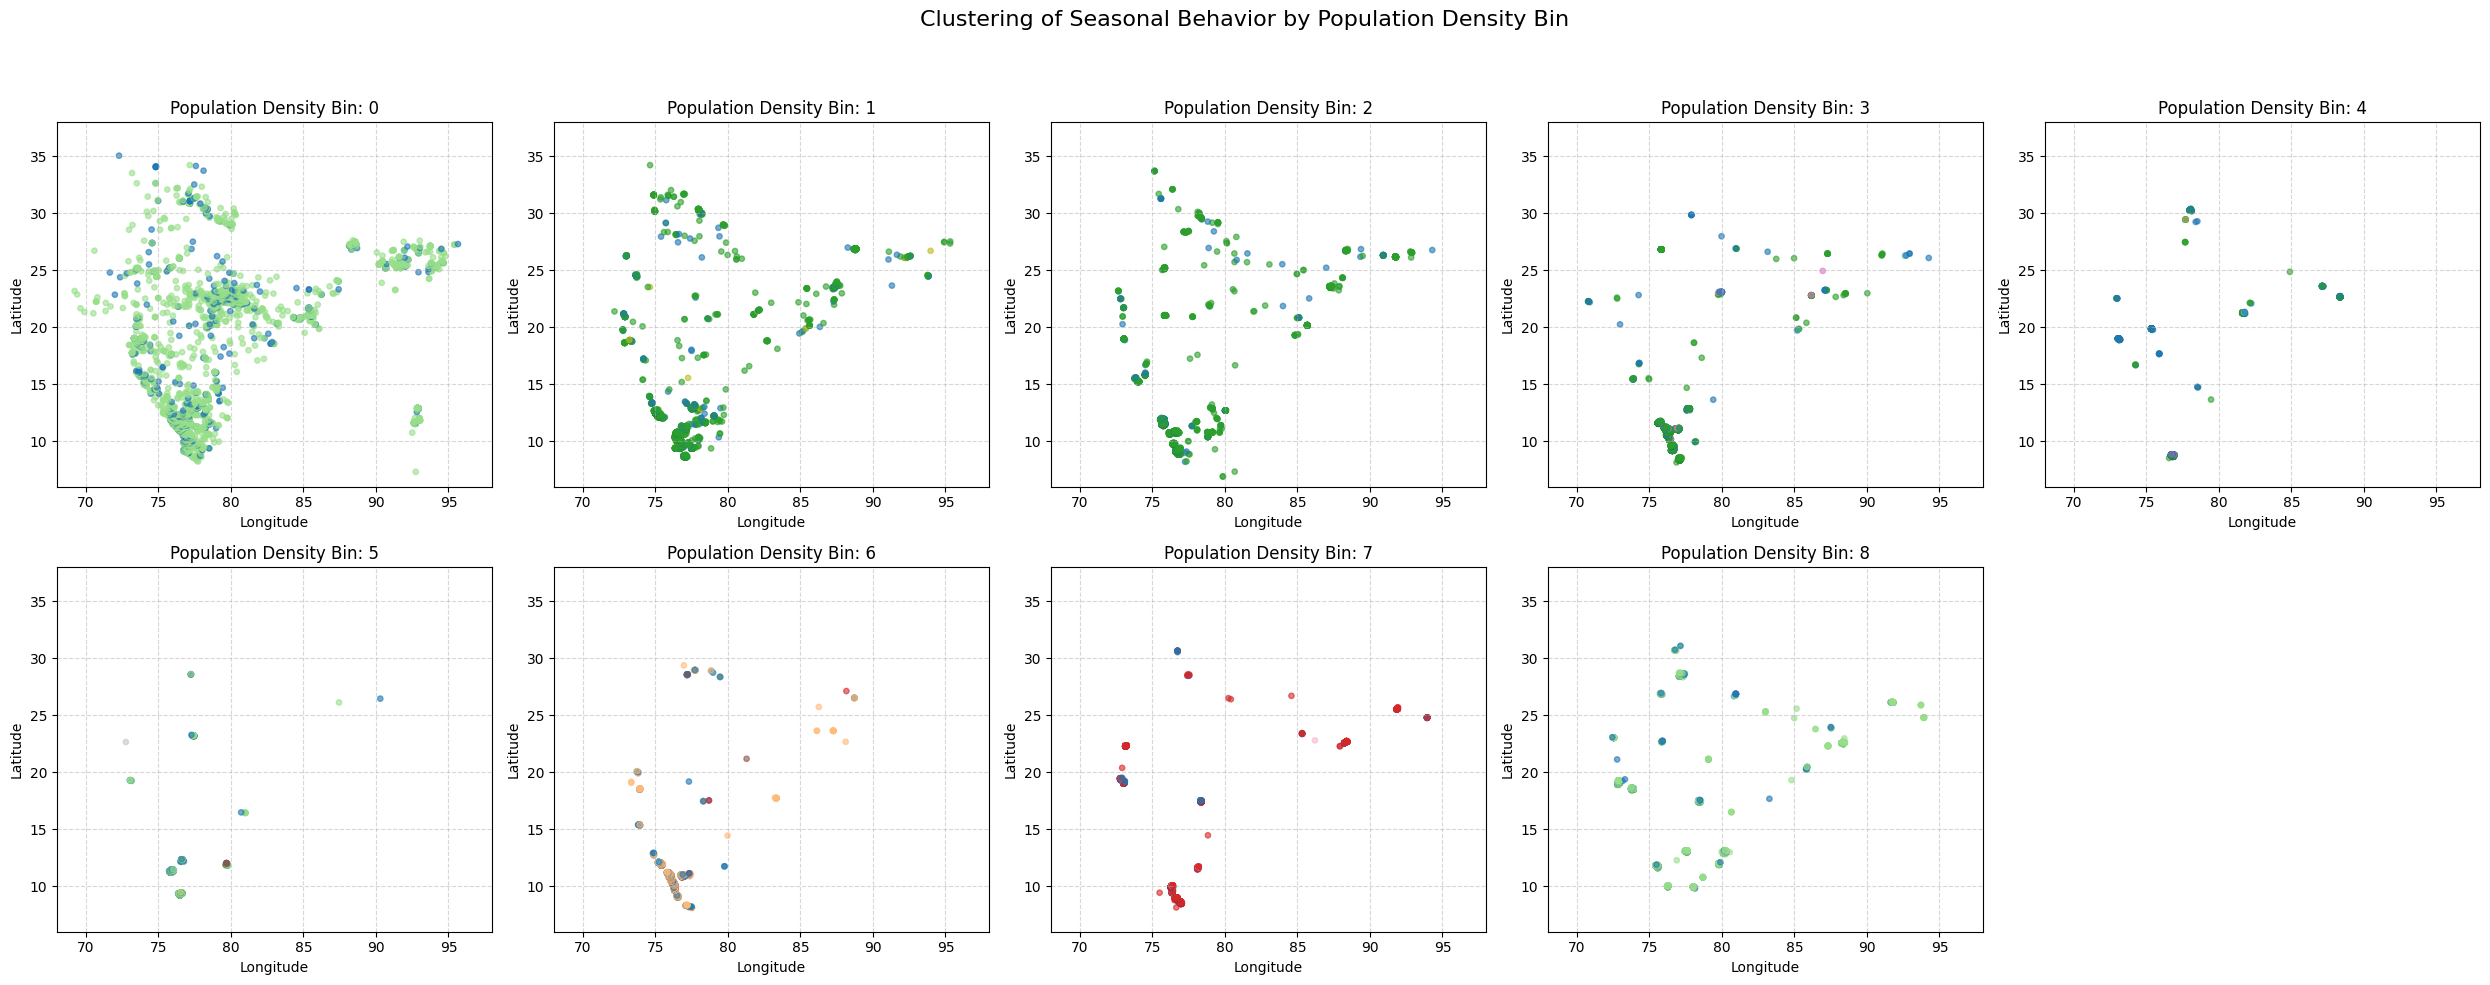

In [10]:
plot_grid(
    urbanization_clusters,
    "Clustering of Seasonal Behavior by Population Density Bin",
    lambda x: f"Population Density Bin: {x}",
)

In [11]:
radiance_clusters = {}

for radiance_dummy in range(2):
    # Filter data for Kerala and for the specific year
    rad_data = data[(data["high_radiance"] == radiance_dummy)]

    if len(rad_data) == 0:
        continue

    rad_aggregated = (
        rad_data.groupby(["Lat", "Long"])[seasonal_columns].mean().reset_index()
    )

    # Handle missing values by marking them as absence (-2) as before
    rad_aggregated = rad_aggregated.fillna(-2)

    # Standardize seasonal data (excluding Lat and Long for spatial reference)
    seasonal_data = rad_aggregated.drop(["Lat", "Long"], axis=1)
    scaler = StandardScaler()
    seasonal_data_scaled = scaler.fit_transform(seasonal_data)

    # Clustering using DBSCAN for the specific year
    dbscan = DBSCAN(
        eps=1.5, min_samples=10
    )  # Parameters may be adjusted based on clustering needs
    clusters = dbscan.fit_predict(seasonal_data_scaled)

    rad_aggregated["Cluster"] = clusters
    radiance_clusters[radiance_dummy] = rad_aggregated



## Comparing Clusters by Radiance Groups

We split the dataset into two groups based on `high_radiance` (e.g., derived from nighttime lights), then rerun clustering within each group.

This allows us to:
- Compare the structure and size of clusters in low vs. high radiance areas
- Analyze how phenological behavior changes with urban intensity


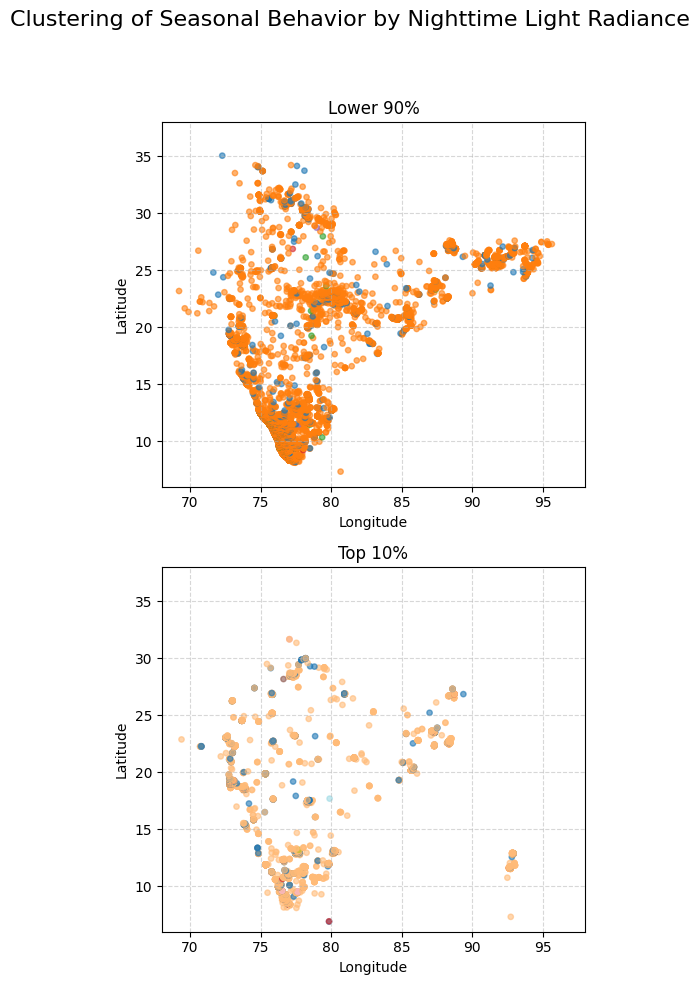

In [12]:
plot_grid(
    radiance_clusters,
    "Clustering of Seasonal Behavior by Nighttime Light Radiance",
    lambda x: "Top 10%" if x == 1 else "Lower 90%",
)


### 📊 Phenophase Distributions by Radiance Group

This plot shows the distribution of 10 seasonal phenophases across two radiance groups — **Low Radiance** (typically rural or less developed areas) and **High Radiance** (typically urban or highly developed areas).

#### ❓ What This Plot Does
- It compares the intensity or frequency of each phenophase (e.g., `Leaves_fresh`, `Fruits_ripe`) between the two groups.
- Each boxplot summarizes:
  - The median value (central line),
  - The interquartile range (the box),
  - Whiskers show the range (excluding outliers).
- Outliers are excluded for cleaner visual comparison.

#### 🧠 Interpretation
- **Leaves_fresh** and **Fruits_ripe** appear more prominent in **high-radiance** areas, possibly reflecting advanced or accelerated vegetation cycles in urban zones.
- **Flowers_male** and **Flowers_female** are more variable in **low-radiance** areas — indicating higher ecological diversity or sampling from more distinct vegetative communities.
- **Leaves_mature** and **Leaves_old** do not show substantial variation between the two groups, suggesting they are **less sensitive to urbanization**.
- **Fruits_open** also tends to be higher in high-radiance areas, reinforcing the idea of urban-associated phenological advancement.

#### 🔍 Why This Matters
Comparing phenophase behavior across radiance levels helps us understand how **urbanization influences vegetation cycles** — useful for urban ecology, biodiversity monitoring, and environmental planning.



=== Radiance Group: Low ===
Cluster Counts:


 0    24310
-1     1340
 1       51
 5       51
 3       35
 2       26
 4       16
 6       14
 8       10
 7        7
Name: Cluster, dtype: int64

Cluster Profiles (mean phenophase values):


,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open
Cluster,,,,,,,,,,
-1,0.845854,1.081951,0.281870,-0.040804,-0.292374,-1.086917,-1.109307,0.020177,0.157716,-1.196911
0,1.104790,1.715274,0.493937,0.403719,0.299259,-1.614788,-1.616983,0.457231,0.271552,-1.466505
1,0.000000,-2.000000,-2.000000,-1.980392,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
2,1.307692,2.000000,-2.000000,1.269231,1.269231,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
3,1.042857,2.000000,0.957143,-2.000000,-2.000000,0.000000,-0.042857,0.514286,0.285714,-2.000000
4,-2.000000,1.015625,0.885417,-2.000000,-2.000000,-2.000000,-2.000000,-1.937500,0.906250,-2.000000
5,1.000000,-2.000000,-2.000000,-2.000000,1.980392,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
6,1.142857,2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,1.500000,-2.000000,-2.000000
7,0.000000,0.000000,0.000000,2.000000,2.000000,-2.000000,-2.000000,2.000000,1.714286,-2.000000



=== Radiance Group: High ===
Cluster Counts:


 0    8537
-1     913
 1      46
 3      21
 2      10
 5       9
 4       6
Name: Cluster, dtype: int64

Cluster Profiles (mean phenophase values):


,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open
Cluster,,,,,,,,,,
-1,0.777576,1.202521,0.354461,-0.174151,-0.030293,-1.368863,-1.417184,-0.035096,0.111816,-1.058488
0,1.064719,1.811462,0.588880,0.291482,0.365551,-1.817350,-1.818479,0.412580,0.305149,-1.390232
1,1.002415,1.983696,0.916063,0.054348,-1.971014,0.025362,0.000000,0.442029,0.173913,-1.948068
2,1.000000,2.000000,-2.000000,1.100000,1.300000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
3,1.123810,1.009524,0.161905,1.142857,1.257143,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
4,1.500000,2.000000,0.000000,0.166667,0.166667,-2.000000,-2.000000,-2.000000,0.000000,0.000000
5,1.666667,2.000000,1.111111,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,1.666667,-2.000000


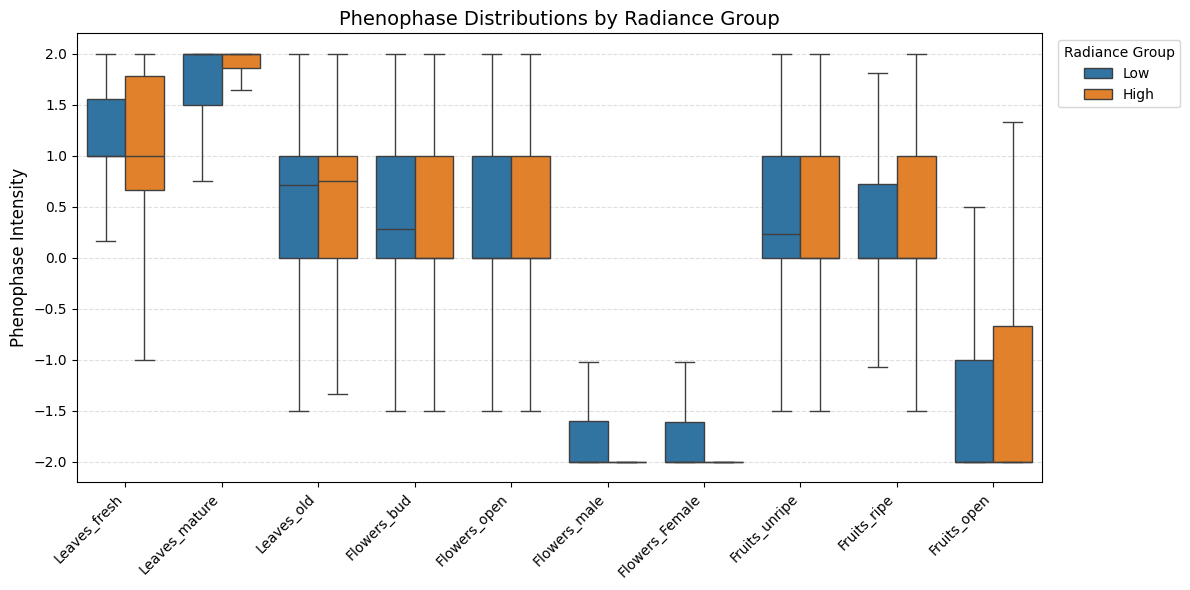

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare the number of clusters and size per radiance group
for rad_level, df in radiance_clusters.items():
    print(f"\n=== Radiance Group: {'High' if rad_level == 1 else 'Low'} ===")
    print("Cluster Counts:")
    display(df["Cluster"].value_counts())

    print("Cluster Profiles (mean phenophase values):")
    display(df.groupby("Cluster")[seasonal_columns].mean())


combined = []
for rad_level, df in radiance_clusters.items():
    temp = df.copy()
    temp["Radiance"] = "High" if rad_level == 1 else "Low"
    combined.append(temp)
combined_df = pd.concat(combined)

# Melt for plotting
melted = combined_df.melt(
    id_vars=["Cluster", "Radiance"],
    value_vars=seasonal_columns,
    var_name="Phenophase",
    value_name="Value",
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=melted,
    x="Phenophase",
    y="Value",
    hue="Radiance",
    palette={"Low": "#1f77b4", "High": "#ff7f0e"},
    showfliers=False,  # <--- removes outliers
    linewidth=1,
)
plt.xticks(rotation=45, ha="right")
plt.title("Phenophase Distributions by Radiance Group", fontsize=14)
plt.xlabel("")
plt.ylabel("Phenophase Intensity", fontsize=12)
plt.legend(title="Radiance Group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
